<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-6-Improvements_NN/Untitled180.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Decomposition Method for Non-smooth Data**


Consider the Heaviside function
$$
H(x) =
\begin{cases}
0, & x < 0, \\
1, & x \geq 0.
\end{cases}
$$

 We consider the boundary value problem
$$
f''(x) = H(x), \quad -1 < x < 1,
$$
with homogeneous Dirichlet boundary conditions
$$
f(-1) = 0, \quad f(1) = 0.
$$
We solve it using neural networks.

Epoch 0, Loss = 0.960225
Epoch 500, Loss = 0.131201
Epoch 1000, Loss = 0.051562
Epoch 1500, Loss = 0.039044
Epoch 2000, Loss = 0.027779
Epoch 2500, Loss = 0.018421
Epoch 3000, Loss = 0.011606
Epoch 3500, Loss = 0.007131
Epoch 4000, Loss = 0.004375
Epoch 4500, Loss = 0.002732
Epoch 5000, Loss = 0.001739


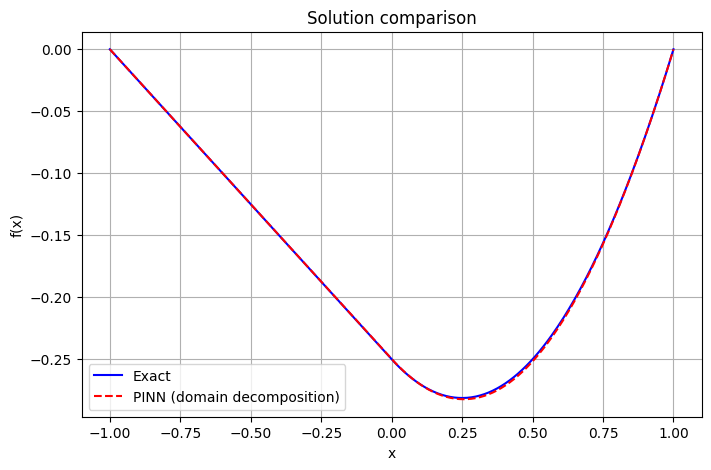

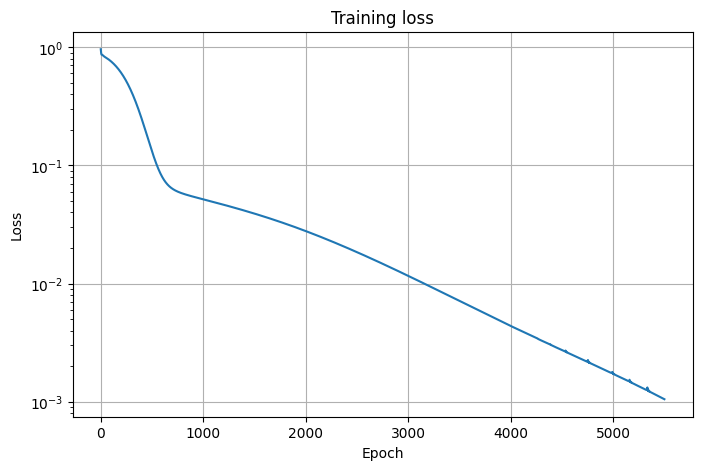

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# Exact solution
# =========================
def exact_solution(x):
    return np.where(x < 0,
                    -0.25*(x+1),
                    0.5*x**2 - 0.25*(x+1))

# =========================
# Neural network model
# =========================
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

# Two subnetworks
model_left = build_model()
model_right = build_model()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# =========================
# Sampling points
# =========================
N = 200

x_left = tf.convert_to_tensor(np.random.uniform(-1, 0, (N,1)), dtype=tf.float32)
x_right = tf.convert_to_tensor(np.random.uniform(0, 1, (N,1)), dtype=tf.float32)

# Boundary points
x_b1 = tf.constant([[-1.0]], dtype=tf.float32)
x_b2 = tf.constant([[1.0]], dtype=tf.float32)

# Interface
x_interface = tf.constant([[0.0]], dtype=tf.float32)

# =========================
# Loss function
# =========================
def compute_loss():
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x_left, x_right])

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x_left, x_right])

            f_left = model_left(x_left)
            f_right = model_right(x_right)

        f_left_x = tape1.gradient(f_left, x_left)
        f_right_x = tape1.gradient(f_right, x_right)

    f_left_xx = tape2.gradient(f_left_x, x_left)
    f_right_xx = tape2.gradient(f_right_x, x_right)

    # PDE residuals
    loss_pde_left = tf.reduce_mean((f_left_xx - 0.0)**2)
    loss_pde_right = tf.reduce_mean((f_right_xx - 1.0)**2)

    # Boundary conditions
    loss_bc = (
        tf.reduce_mean(tf.square(model_left(x_b1))) +
        tf.reduce_mean(tf.square(model_right(x_b2)))
    )

    # Interface continuity
    f_l_0 = model_left(x_interface)
    f_r_0 = model_right(x_interface)

    # Derivatives at interface
    with tf.GradientTape() as tape:
        tape.watch(x_interface)
        f_l = model_left(x_interface)
    f_l_x = tape.gradient(f_l, x_interface)

    with tf.GradientTape() as tape:
        tape.watch(x_interface)
        f_r = model_right(x_interface)
    f_r_x = tape.gradient(f_r, x_interface)

    loss_interface = tf.reduce_mean(tf.square(f_l_0 - f_r_0))
    loss_flux = tf.reduce_mean(tf.square(f_l_x - f_r_x))

    total_loss = (
        loss_pde_left + loss_pde_right
        + 10*loss_bc
        + 10*loss_interface
        + 10*loss_flux
    )

    return total_loss

# =========================
# Training loop
# =========================
EPOCHS = 5500
loss_history = []

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        loss = compute_loss()

    grads = tape.gradient(
        loss,
        model_left.trainable_variables +
        model_right.trainable_variables
    )

    optimizer.apply_gradients(zip(
        grads,
        model_left.trainable_variables +
        model_right.trainable_variables
    ))

    loss_value = loss.numpy().item()   # ✅ FIXED
    loss_history.append(loss_value)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss_value:.6f}")

# =========================
# Evaluation
# =========================
x_plot = np.linspace(-1, 1, 400).reshape(-1,1)

mask_left = x_plot[:,0] < 0
mask_right = x_plot[:,0] >= 0

x_left_plot = x_plot[mask_left]
x_right_plot = x_plot[mask_right]

f_left_pred = model_left(x_left_plot).numpy().flatten()
f_right_pred = model_right(x_right_plot).numpy().flatten()

# Assemble solution (1D)
f_pred = np.zeros(x_plot.shape[0])
f_pred[mask_left] = f_left_pred
f_pred[mask_right] = f_right_pred

# Exact
f_exact = exact_solution(x_plot[:,0])

# =========================
# Plot solution
# =========================
plt.figure(figsize=(8,5))
plt.plot(x_plot[:,0], f_exact, 'b-', label='Exact')
plt.plot(x_plot[:,0], f_pred, 'r--', label='PINN (domain decomposition)')
plt.legend()
plt.title("Solution comparison")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

# =========================
# Plot loss
# =========================
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.yscale('log')
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

The next code solves the same problem using Runge--Kuta method.

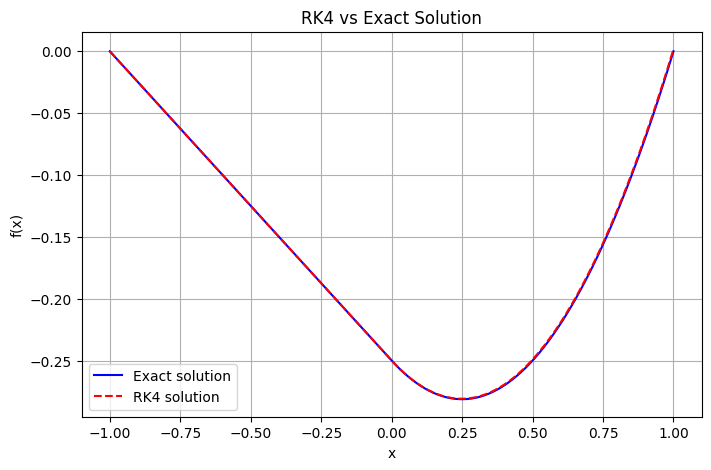

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Heaviside function
# =========================
def H(x):
    return 0.0 if x < 0 else 1.0

# =========================
# System: y' = F(x,y)
# =========================
def F(x, y):
    y1, y2 = y
    return np.array([y2, H(x)])

# =========================
# RK4 solver
# =========================
def rk4(f, x0, y0, h, N):
    x_vals = [x0]
    y_vals = [y0]

    x = x0
    y = np.array(y0)

    for _ in range(N):
        k1 = f(x, y)
        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + h/2, y + h*k2/2)
        k4 = f(x + h, y + h*k3)

        y = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        x = x + h

        x_vals.append(x)
        y_vals.append(y.copy())

    return np.array(x_vals), np.array(y_vals)

# =========================
# Exact solution
# =========================
def exact(x):
    return np.where(x < 0,
                    -0.25*(x+1),
                    0.5*x**2 - 0.25*(x+1))

# =========================
# Solve
# =========================
x0 = -1
y0 = [0.0, -0.25]   # [f(-1), f'(-1)]
h = 0.01
N = int((1 - (-1)) / h)

x_rk, y_rk = rk4(F, x0, y0, h, N)

f_rk = y_rk[:,0]

# =========================
# Exact solution
# =========================
x_exact = np.linspace(-1,1,400)
f_exact = exact(x_exact)

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))

plt.plot(x_exact, f_exact, 'b-', label='Exact solution')
plt.plot(x_rk, f_rk, 'r--', label='RK4 solution')

plt.legend()
plt.title("RK4 vs Exact Solution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

# **Jump Solution**

Now we consider the same differential equation with the same boundary conditions
$$
f(-1) = 0, \qquad f(1) = 0,
$$
but we impose a discontinuity at $x=0$:
$$
f(0^-) = 1, \qquad f(0^+) = \frac{1}{2}.
$$

As before, solving the equation separately on the subdomains $(-1,0)$ and $(0,1)$ leads to a general solution depending on four constants. The boundary and interface conditions provide four linear relations, which uniquely determine these constants. The resulting solution is
\begin{align*}
f(x) =
\begin{cases}
x+1, & x < 0, \\[6pt]
\frac{1}{2}x^2 - x + \frac{1}{2}, & x \geq 0.
\end{cases}
\end{align*}

Epoch 0, Loss = 16.054760
Epoch 500, Loss = 1.233357
Epoch 1000, Loss = 0.111745
Epoch 1500, Loss = 0.067618
Epoch 2000, Loss = 0.048402
Epoch 2500, Loss = 0.034979
Epoch 3000, Loss = 0.025037
Epoch 3500, Loss = 0.017602
Epoch 4000, Loss = 0.012094
Epoch 4500, Loss = 0.008216
Epoch 5000, Loss = 0.005741


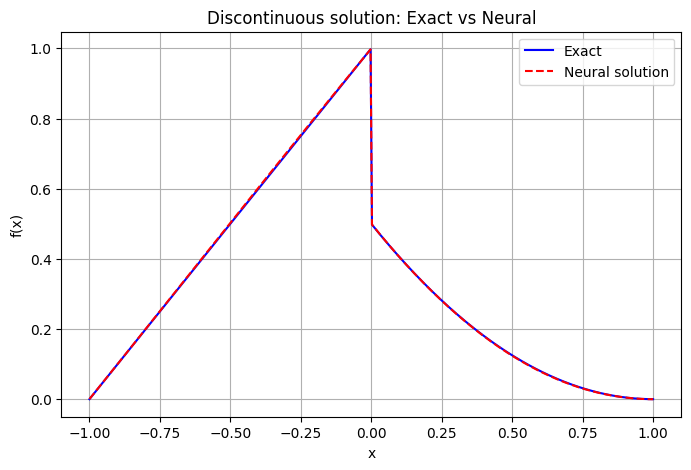

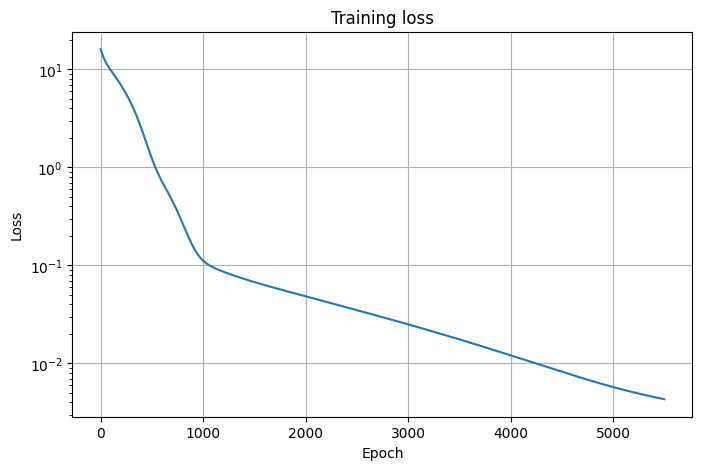

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# Exact solution
# =========================
def exact_solution(x):
    return np.where(x < 0,
                    x + 1,
                    0.5*x**2 - x + 0.5)

# =========================
# Neural network
# =========================
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

# Two subnetworks
model_left = build_model()
model_right = build_model()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# =========================
# Sampling
# =========================
N = 200

x_left = tf.convert_to_tensor(np.random.uniform(-1, 0, (N,1)), dtype=tf.float32)
x_right = tf.convert_to_tensor(np.random.uniform(0, 1, (N,1)), dtype=tf.float32)

# Boundary
x_b1 = tf.constant([[-1.0]], dtype=tf.float32)
x_b2 = tf.constant([[1.0]], dtype=tf.float32)

# Interface
x_interface = tf.constant([[0.0]], dtype=tf.float32)

# =========================
# Loss function
# =========================
def compute_loss(alpha=10, beta=10, gamma=10):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x_left, x_right])

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x_left, x_right])

            f_left = model_left(x_left)
            f_right = model_right(x_right)

        f_left_x = tape1.gradient(f_left, x_left)
        f_right_x = tape1.gradient(f_right, x_right)

    f_left_xx = tape2.gradient(f_left_x, x_left)
    f_right_xx = tape2.gradient(f_right_x, x_right)

    # PDE losses
    loss_pde_left = tf.reduce_mean(tf.square(f_left_xx - 0.0))
    loss_pde_right = tf.reduce_mean(tf.square(f_right_xx - 1.0))

    # Boundary loss
    loss_bc = (
        tf.reduce_mean(tf.square(model_left(x_b1))) +
        tf.reduce_mean(tf.square(model_right(x_b2)))
    )

    # Interface (discontinuous conditions)
    loss_interface_left = tf.reduce_mean(
        tf.square(model_left(x_interface) - 1.0)
    )

    loss_interface_right = tf.reduce_mean(
        tf.square(model_right(x_interface) - 0.5)
    )

    total_loss = (
        loss_pde_left + loss_pde_right
        + alpha * loss_bc
        + beta * loss_interface_left
        + gamma * loss_interface_right
    )

    return total_loss

# =========================
# Training
# =========================
EPOCHS = 5500
loss_history = []

for epoch in range(EPOCHS):

    with tf.GradientTape() as tape:
        loss = compute_loss()

    grads = tape.gradient(
        loss,
        model_left.trainable_variables +
        model_right.trainable_variables
    )

    optimizer.apply_gradients(zip(
        grads,
        model_left.trainable_variables +
        model_right.trainable_variables
    ))

    loss_value = loss.numpy().item()
    loss_history.append(loss_value)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss_value:.6f}")

# =========================
# Evaluation
# =========================
x_plot = np.linspace(-1,1,400).reshape(-1,1)

mask_left = x_plot[:,0] < 0
mask_right = x_plot[:,0] >= 0

x_left_plot = x_plot[mask_left]
x_right_plot = x_plot[mask_right]

f_left_pred = model_left(x_left_plot).numpy().flatten()
f_right_pred = model_right(x_right_plot).numpy().flatten()

# Assemble
f_pred = np.zeros(x_plot.shape[0])
f_pred[mask_left] = f_left_pred
f_pred[mask_right] = f_right_pred

# Exact
f_exact = exact_solution(x_plot[:,0])

# =========================
# Plot solution
# =========================
plt.figure(figsize=(8,5))
plt.plot(x_plot[:,0], f_exact, 'b-', label='Exact')
plt.plot(x_plot[:,0], f_pred, 'r--', label='Neural solution')
plt.legend()
plt.title("Discontinuous solution: Exact vs Neural")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

# =========================
# Plot loss
# =========================
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.yscale('log')
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()